In [30]:
# ============================================
# TEMPLATE PREPROCESSING - REUSABLE
# ============================================

# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (classification_report, 
                             roc_auc_score, 
                             ConfusionMatrixDisplay)

# Decision Tree and Random Forest models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# 1. LOAD DATA
# --------------------------------------------
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')

# --------------------------------------------
# 2. CLEANING
# --------------------------------------------
# TotalCharges has hidden spaces ' ' → convert to numeric
# errors='coerce' turns invalid values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with NaN (only 11 rows affected)
df.dropna(inplace=True)

# Drop customer ID → not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Encode target variable as binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --------------------------------------------
# 3. DEFINE FEATURES
# --------------------------------------------
# Continuous columns → will be scaled
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Categorical columns → will be one-hot encoded
# Automatically selects all columns except continuous and target
categorical_cols = [col for col in df.columns 
                    if col not in continuous_cols + ['Churn']]

# --------------------------------------------
# 4. ONE-HOT ENCODING
# --------------------------------------------
# drop_first=True avoids the dummy variable trap
# e.g. Gender: Male/Female → only Female column kept
df_encoded = pd.get_dummies(df, 
                             columns=categorical_cols, 
                             drop_first=True)

# --------------------------------------------
# 5. SPLIT X AND y
# --------------------------------------------
# X → all features (everything except target)
# y → target variable (Churn)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# --------------------------------------------
# 6. TRAIN/TEST SPLIT
# --------------------------------------------
# test_size=0.2 → 80% train, 20% test
# stratify=y → preserves class balance in both sets
# random_state=42 → reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# 7. SCALING (continuous columns only)
# --------------------------------------------
# fit_transform on train → learns mean and std from train only
# transform on test → applies same scaling (no data leakage)
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("✅ Preprocessing complete")
print(f"   Train set: {X_train.shape}")
print(f"   Test set:  {X_test.shape}")
print(f"   Churn rate: {y.mean():.2%}")

✅ Preprocessing complete
   Train set: (5625, 30)
   Test set:  (1407, 30)
   Churn rate: 26.58%


In [31]:
# ── IMPORTS ──────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

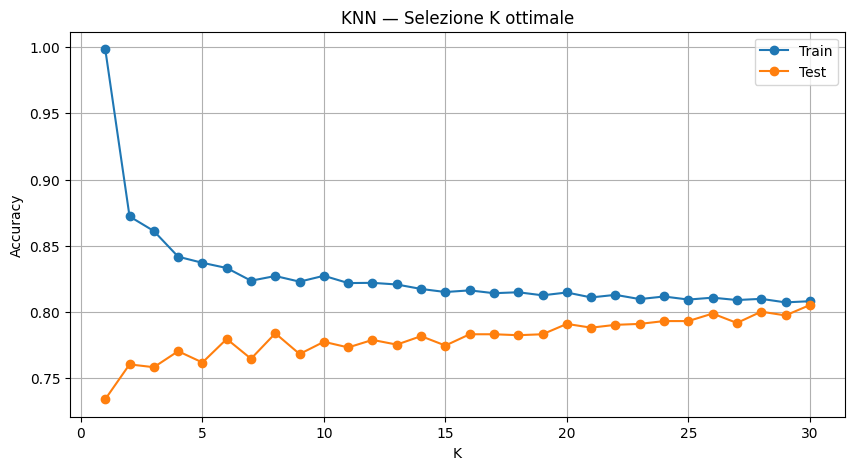

In [32]:
# ── FIND OPTIMAL K ─────────────────────────────────

train_scores = []
test_scores  = []
k_range      = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, label='Train', marker='o')
plt.plot(k_range, test_scores,  label='Test',  marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN — Selezione K ottimale')
plt.legend()
plt.grid(True)
plt.show()


In [33]:
#FINAL MODEL WITH k=27
knn = KNeighborsClassifier(
    n_neighbors=27,
    metric='minkowski',
    weights='uniform',
    p = 2
)
knn.fit(X_train, y_train)

#prediction
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:,1]

print("=== KNN ===")
print(classification_report(y_test,y_pred))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}')

=== KNN ===
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.61      0.59      0.60       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407

AUC-ROC: 0.828


# 📊 KNN Analysis — Telco Churn

---

## Tabella comparativa

| Metrica | Decision Tree | Random Forest | KNN |
|---|---|---|---|
| Accuracy | 0.78 | 0.79 | 0.79 |
| AUC-ROC | 0.820 | 0.832 | 0.828 |
| Churn Recall | 0.50 | 0.40 | **0.59** |
| Churn Precision | 0.61 | 0.67 | 0.61 |
| F1 Churn | 0.55 | 0.50 | **0.60** |

---

## Scelta del modello

**KNN** è il modello preferibile in questo contesto business.
Il **Recall sulla classe Churn** è il più alto tra i tre modelli (0.59):
> Su 100 clienti che abbandoneranno, KNN ne identifica 59 in anticipo,
> contro 50 del Decision Tree e solo 40 della Random Forest.

In un contesto di customer retention, un **falso negativo** (cliente
a rischio non identificato) costa molto di più di un **falso positivo**
(cliente contattato inutilmente).

---

## K ottimale

Osservando il grafico Train vs Test score:

- **K=1** → overfitting evidente (train=1.0, test=0.74)
- **K=6** → test score ancora instabile
- **K=27** → test score massimo e stabile (~0.79-0.80), gap ridotto
- **K dispari** → scelto per evitare pareggi nel voto di maggioranza

---

## Limitazioni KNN

- **Lento** su dataset grandi — calcola distanza da tutti i punti del train
- Richiede **sempre StandardScaler** — sensibile alla scala delle feature
- **Nessuna interpretabilità** — non indica quali feature contano di più
- Soffre della **curse of dimensionality** — con molte feature le distanze perdono significato

---

## Confronto finale — quando usare quale modello

| Obiettivo | Modello consigliato |
|---|---|
| Massimo recall (retention clienti) | **KNN** |
| Interpretabilità per stakeholder | **Decision Tree** |
| Robustezza generale | **Random Forest** |
| Feature importance | **Random Forest** |

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#model 
lda = LinearDiscriminantAnalysis()

#fit
lda.fit(X_train, y_train)

#predict
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:,1]

print("=== LDA ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

=== LDA ===
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407

AUC-ROC: 0.828


In [35]:
# dizionario con tutti i risultati
results = {
    'Model':     ['DT',   'RF',   'KNN',  'LDA'],
    'Accuracy':  [0.78,   0.79,   0.79,   0.79],
    'AUC-ROC':   [0.820,  0.832,  0.828,  0.828],
    'Recall':    [0.50,   0.40,   0.59,   0.56],
    'Precision': [0.61,   0.67,   0.61,   0.62],
    'F1':        [0.55,   0.50,   0.60,   0.59]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Model  Accuracy  AUC-ROC  Recall  Precision   F1
   DT      0.78    0.820    0.50       0.61 0.55
   RF      0.79    0.832    0.40       0.67 0.50
  KNN      0.79    0.828    0.59       0.61 0.60
  LDA      0.79    0.828    0.56       0.62 0.59


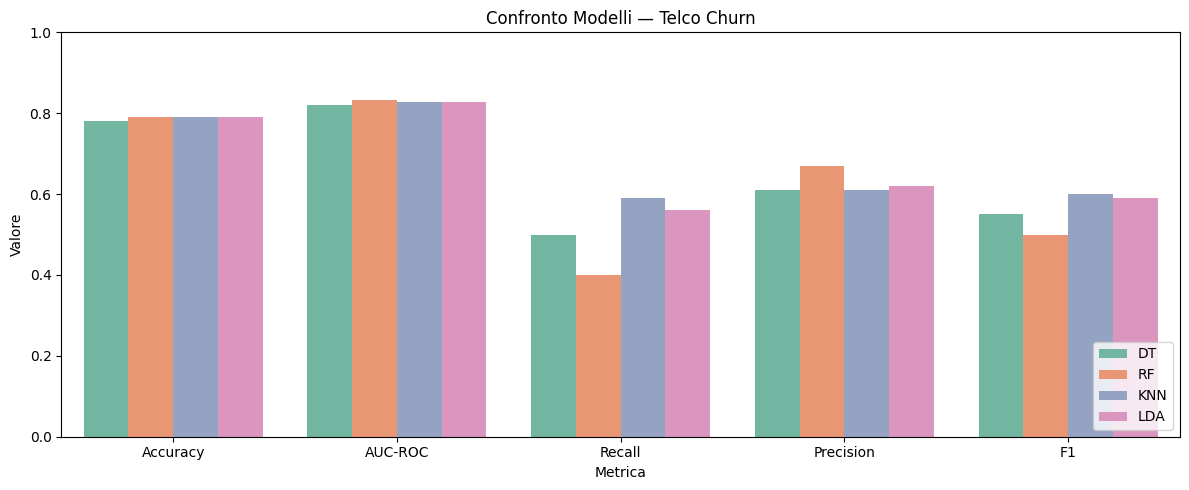

In [36]:
# Barplot comparativo
results_melted = results_df.melt(
    id_vars='Model',
    var_name='Metrica',
    value_name='Valore'
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted,
            x='Metrica',
            y='Valore',
            hue='Model',
            palette='Set2')
plt.title('Confronto Modelli — Telco Churn')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### LDA 

LDA e KNN sono quasi equivalenti su questo dataset.
Questo suggerisce che i dati hanno una struttura
abbastanza lineare — LDA riesce a catturarla
quasi quanto KNN che è più flessibile.

Se i dati fossero molto non-lineari:
→ LDA degraderebbe molto
→ KNN resterebbe stabile

In [37]:
#SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

#model
svm = SVC(
    kernel = 'rbf',
    C = 1.0,
    gamma= 'scale',
    probability= True,
    random_state= 42
)

#FIT
svm.fit(X_train, y_train)

#PREDICT
y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)[:,1]

print("=== SVM ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

#SUPPORT VECTORS
print(f"Support Vectors: {svm.n_support_}")

=== SVM ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

AUC-ROC: 0.783
Support Vectors: [1393 1210]


## ⚠️ Note su SVM — Perché non è il modello adatto

### Performance

| Metrica | Valore | Confronto |
|---|---|---|
| AUC-ROC | 0.783 | Peggiore tra tutti i modelli |
| Churn Recall | 0.48 | Secondo peggiore dopo RF |
| Churn Precision | 0.65 | Seconda migliore dopo RF |
| F1 Churn | 0.55 | Tra i peggiori |

### Analisi Support Vectors

```python
Support Vectors per classe: [1393, 1210]
Totale SV: 2603 su 5634 campioni di train = 46%
```

Un numero così alto di Support Vectors indica che
le classi si sovrappongono fortemente nello spazio
delle feature — SVM fatica a trovare un confine netto.

### Perché SVM non funziona bene qui

| Problema | Dettaglio |
|---|---|
| Dataset grande (~7000 righe) | SVM scala male — O(n²) |
| Classi sovrapposte | 46% dei campioni sono Support Vectors |
| Molte feature categoriali | SVM preferisce feature continue |
| Dataset sbilanciato | Privilegia la classe maggioritaria (74% No Churn) |
| probability=True | Probabilità approssimate → AUC-ROC penalizzato |

### Quando SVM funziona meglio

> SVM è ideale con **pochi campioni**, **molte feature continue**
> e **classi ben separabili** — condizioni non presenti
> in questo dataset.

# 📊 Analisi Comparativa Modelli — Telco Customer Churn

---

## Confronto Performance

| Metrica | DT | RF | KNN | LDA | SVM |
|---|---|---|---|---|---|
| Accuracy | 0.78 | 0.79 | 0.79 | 0.79 | 0.79 |
| AUC-ROC | 0.820 | 0.832 | **0.828** | 0.828 | 0.783 |
| Churn Recall | 0.50 | 0.40 | **0.59** | 0.56 | 0.48 |
| Churn Precision | 0.61 | **0.67** | 0.61 | 0.62 | 0.65 |
| F1 Churn | 0.55 | 0.50 | **0.60** | 0.59 | 0.55 |

> **Metrica prioritaria:** Recall sulla classe Churn.
> In un contesto di customer retention, un falso negativo
> (cliente a rischio non identificato) ha un costo
> stimato 5-7x superiore a un falso positivo.

---

## 🏆 Modello Selezionato: KNN (K=27)

KNN ottiene le migliori performance sulle metriche prioritarie:

| Vantaggio | Dettaglio |
|---|---|
| Recall più alto (0.59) | Su 100 clienti a rischio, ne identifica 59 in anticipo |
| F1 più alto (0.60) | Miglior bilanciamento tra precision e recall |
| AUC-ROC solido (0.828) | Secondo migliore — buon ranking delle probabilità |

---

## 📋 Note sui Modelli

### Random Forest
Migliore AUC-ROC (0.832) ma recall più basso (0.40).
Preferibile quando la priorità è la precisione
piuttosto che la copertura dei clienti a rischio.

### Decision Tree
Massima interpretabilità — ogni decisione
è spiegabile a stakeholder non tecnici.
Utile per presentare le regole di churn
al team business.

### LDA
Performance quasi equivalente a KNN
(recall 0.56 vs 0.59) con un vantaggio:
non richiede la ricerca di iperparametri.
Buona alternativa se il dataset
soddisfa le assunzioni di normalità.

### SVM ⚠️
Performance più debole su questo dataset:
- **AUC-ROC 0.783** — probabilità non calibrate
- **Recall 0.48** — peggiore dopo RF
- **Support Vectors: 2603/5634 (46%)** — indica forte sovrapposizione tra classi

SVM non è il modello adatto per questo caso:
dataset grande, classi sovrapposte e molte
feature categoriali ne limitano l'efficacia.

---

## 💡 Raccomandazioni Business

| Obiettivo | Modello | Motivazione |
|---|---|---|
| Massimizzare clienti salvati | **KNN** | Recall più alto |
| Spiegare decisioni al management | **Decision Tree** | Massima interpretabilità |
| Robustezza su nuovi dati | **Random Forest** | AUC-ROC più alto |
| Deploy veloce senza tuning | **LDA** | Nessun iperparametro |

---

## ⚠️ Limitazioni e Prossimi Step

- **Dataset sbilanciato** (26% churn / 74% no churn)
  → Testare `class_weight='balanced'` su tutti i modelli
- **Multicollinearità** tra `tenure` e `TotalCharges`
  → Valutare rimozione di `TotalCharges`
- **Ottimizzazione iperparametri**
  → Grid Search su KNN e RF per migliorare il recall
- **Cross-validation**
  → Verificare stabilità dei risultati con K-Fold